
# Final STO-DA Evaluation on 127 Held-Out Rye Days — Corrected Version
## DET vs STO vs Perfect Foresight (PF), GC and IS

This notebook is the corrected, complete final STO-DA evaluation workflow.

### Frozen scenario settings

\[
N_0=5000,\qquad K^\star=50.
\]

No scenario-count tuning is performed on the 127 held-out days.

### Important solver correction

Earlier default HiGHS MIP tolerances allowed a few cases in which the reported PF objective was very slightly above the realized DET/STO objective (worst observed difference about 0.023 NOK). This is a solver-optimality-gap artifact, not a modeling result.

This notebook therefore:

1. uses explicit HiGHS MIP tolerances,
2. supports a **strict PF correction path** so an already completed 1016-case DET/STO run does **not** have to be repeated,
3. recomputes all PF-dependent metrics after strict PF replacement,
4. validates the corrected dataset before producing the final summary.

### Recommended path for the current project

Because the full 127-day DET/STO/PF run has already completed, use:

**Existing full results → strict PF re-solve (254 cases only) → merge → validate → summarize.**

A clean full rerun is also supported if needed later.


In [21]:

# Run only if required in the active environment.
%pip install -q pyomo highspy pandas numpy scipy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [22]:

from pathlib import Path
import json
import heapq
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist
import pyomo.environ as pyo

ROOT = Path.cwd()

def find_file(filename):
    candidates = [
        ROOT / filename,
        ROOT / "data" / filename,
        ROOT / "config" / filename,
        Path("/mnt/data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not locate {filename}. Tried: {candidates}")

DEV_FILE = find_file("rye_development_304days.csv")
OOS_FILE = find_file("rye_oos_127days.csv")

for pname in (
    "study_parameters_frozen_v5.json",
    "study_parameters_frozen_v4.json",
    "study_parameters_frozen_v3.json",
):
    try:
        PARAM_FILE = find_file(pname)
        break
    except FileNotFoundError:
        PARAM_FILE = None

if PARAM_FILE is None:
    raise FileNotFoundError("Could not find study parameter JSON.")

dev = pd.read_csv(DEV_FILE)
oos = pd.read_csv(OOS_FILE)

with open(PARAM_FILE, "r", encoding="utf-8") as f:
    CFG = json.load(f)

print("Development days:", dev["date_utc"].nunique())
print("Held-out OOS days:", oos["date_utc"].nunique())
print("Parameter file:", PARAM_FILE)


Development days: 304
Held-out OOS days: 127
Parameter file: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS\config\study_parameters_frozen_v4.json


In [23]:

# ---------- Frozen parameters ----------
T = CFG["time"]["T_hours"]
DT = CFG["time"]["delta_t_h"]

PV_RATED = CFG["rye_physical_system"]["pv_rated_kwp"]
WIND_RATED = CFG["rye_physical_system"]["wind_rated_kw"]
BESS_E = CFG["rye_physical_system"]["bess_energy_kwh"]
P_CH_MAX = CFG["rye_physical_system"]["bess_charge_max_kw"]
P_DIS_MAX = CFG["rye_physical_system"]["bess_discharge_max_kw"]
ETA_CH = CFG["rye_physical_system"]["eta_charge"]
ETA_DIS = CFG["rye_physical_system"]["eta_discharge"]

SOC_MIN = CFG["bess_study_settings"]["soc_min"]
SOC_MAX = CFG["bess_study_settings"]["soc_max"]
SOC_INIT = CFG["bess_study_settings"]["soc_initial"]
SOC_TERM = CFG["bess_study_settings"]["soc_terminal"]

DG_MIN = CFG["study_added_diesel_generator"]["p_min_kw"]
DG_MAX = CFG["study_added_diesel_generator"]["p_max_kw"]
C_DG = CFG["study_added_diesel_generator"]["marginal_cost_nok_per_kwh"]

GRID_IMPORT_MAX = CFG["grid"]["import_max_kw"]
GRID_EXPORT_MAX = CFG["grid"]["export_max_kw"]
GRID_TARIFF = CFG["grid"]["energy_tariff_nok_per_kwh"]
SELL_FACTOR = CFG["grid"]["sell_price_fraction_of_buy"]

CRIT_SHARE = CFG["load_priority"]["critical_fraction"]
NCRIT_SHARE = CFG["load_priority"]["noncritical_fraction"]

C_BATT = CFG["objective_coefficients"]["battery_throughput_nok_per_kwh"]
C_CURT = CFG["objective_coefficients"]["renewable_curtailment_nok_per_kwh"]
C_SHED_N = CFG["objective_coefficients"]["noncritical_shedding_penalty_nok_per_kwh"]
C_SHED_C = CFG["objective_coefficients"]["critical_shedding_penalty_nok_per_kwh"]

ALPHAS = CFG["uncertainty"]["alpha_levels"]
N0 = CFG["uncertainty"]["initial_monte_carlo_scenarios"]
K_FINAL = CFG["uncertainty"].get("final_reduced_scenarios", 50)
BASE_SEED = CFG["uncertainty"]["random_seed"]
CONFIDENCE = CFG["evaluation"]["confidence_level"]

# Solver settings.
# MAIN gap is used only if a clean full rerun is requested.
# STRICT PF gap is used for the benchmark correction.
MAIN_MIP_REL_GAP = 1e-6
MAIN_MIP_ABS_GAP = 1e-7
STRICT_PF_MIP_REL_GAP = 1e-9
STRICT_PF_MIP_ABS_GAP = 1e-9
VALIDATION_ABS_TOL = 1e-6

assert N0 == 5000
assert K_FINAL == 50
assert len(oos["date_utc"].astype(str).unique()) == 127

print("Frozen N0 =", N0)
print("Frozen K  =", K_FINAL)
print("Alpha levels =", ALPHAS)
print("Main MIP rel gap =", MAIN_MIP_REL_GAP)
print("Strict PF MIP rel gap =", STRICT_PF_MIP_REL_GAP)


Frozen N0 = 5000
Frozen K  = 50
Alpha levels = [0.05, 0.1, 0.2, 0.3]
Main MIP rel gap = 1e-06
Strict PF MIP rel gap = 1e-09



## 1. Common OOS trajectory and forecast construction

The measured Rye data are the realized ground truth. For each held-out day and uncertainty level, DET and STO receive the same controlled point forecast.

\[
X_t^{real}=\hat X_t(1+e_t).
\]

The exact deterministic seed rule from the DET/PF baseline notebook is retained.


In [24]:

def oos_forecast_seed(date_string, alpha, base_seed=BASE_SEED):
    date_num = int(str(date_string).replace("-", ""))
    alpha_num = int(round(alpha * 1000))
    return (base_seed + date_num * 1009 + alpha_num * 9176) % (2**32 - 1)


def get_day(df, date_string):
    x = df[df["date_utc"].astype(str) == str(date_string)].copy()
    x = x.sort_values("hour_utc")
    if len(x) != 24:
        raise ValueError(f"{date_string}: expected 24 rows, got {len(x)}")

    day = pd.DataFrame({
        "hour": np.arange(24),
        "pv": x["pv_clean_kw"].to_numpy(float),
        "wind": x["wind_clean_kw"].to_numpy(float),
        "load": x["load_kw"].to_numpy(float),
        "spot": x["spot_price_nok_per_kwh"].to_numpy(float),
    })
    day["buy_price"] = day["spot"] + GRID_TARIFF
    day["sell_price"] = SELL_FACTOR * day["buy_price"]
    day["load_crit"] = CRIT_SHARE * day["load"]
    day["load_ncrit"] = NCRIT_SHARE * day["load"]
    return day


def make_controlled_forecast(actual, alpha, seed):
    rng = np.random.default_rng(seed)
    fc = actual.copy()

    for col, cap in [("pv", PV_RATED), ("wind", WIND_RATED), ("load", None)]:
        realized = actual[col].to_numpy(float)
        e = rng.normal(0.0, alpha, size=24)
        e = np.clip(e, -0.80, 1.50)

        forecast = realized / (1.0 + e)
        forecast = np.maximum(forecast, 0.0)
        if cap is not None:
            forecast = np.minimum(forecast, cap)

        fc[col] = forecast

    fc["load_crit"] = CRIT_SHARE * fc["load"]
    fc["load_ncrit"] = NCRIT_SHARE * fc["load"]
    return fc


_oos_counts = oos.groupby("date_utc").size()
assert len(_oos_counts) == 127
assert (_oos_counts == 24).all()

print("OOS data integrity check PASSED.")


OOS data integrity check PASSED.



## 2. Frozen \(K=50\) BRA template


In [25]:

def bra_seed(*parts, base=BASE_SEED):
    value = int(base)
    for p in parts:
        for ch in str(p):
            value = (value * 131 + ord(ch)) % (2**32 - 1)
    return value


def generate_error_pool(alpha, n_scenarios, seed):
    rng = np.random.default_rng(seed)
    e_pv = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_w = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    e_l = rng.normal(0.0, alpha, size=(n_scenarios, 24))
    errors = np.concatenate([e_pv, e_w, e_l], axis=1).astype(np.float32)
    probs = np.full(n_scenarios, 1.0 / n_scenarios, dtype=np.float64)
    return errors, probs


def backward_reduction_to_target(errors, probabilities, target_count):
    errors = np.asarray(errors, dtype=np.float32)
    probs = np.asarray(probabilities, dtype=np.float64).copy()
    n = len(probs)

    D = cdist(errors, errors, metric="euclidean").astype(np.float32)
    np.fill_diagonal(D, np.inf)

    active = np.ones(n, dtype=bool)
    version = np.zeros(n, dtype=np.int64)

    def nearest_active(i):
        work = D[i].copy()
        work[~active] = np.inf
        work[i] = np.inf
        j = int(np.argmin(work))
        return j, float(work[j])

    heap = []
    for i in range(n):
        _, d = nearest_active(i)
        heapq.heappush(heap, (probs[i] * d, i, version[i]))

    remaining = n
    while remaining > target_count:
        while True:
            old_cost, i, ver = heapq.heappop(heap)
            if not active[i] or ver != version[i]:
                continue

            j, d = nearest_active(i)
            true_cost = probs[i] * d
            if true_cost > old_cost + 1e-12:
                version[i] += 1
                heapq.heappush(heap, (true_cost, i, version[i]))
                continue
            break

        removed_prob = probs[i]
        active[i] = False
        probs[i] = 0.0
        remaining -= 1

        probs[j] += removed_prob
        version[j] += 1

        if remaining > 1:
            _, d2 = nearest_active(j)
            heapq.heappush(heap, (probs[j] * d2, j, version[j]))

    idx = np.where(active)[0]
    pr = probs[idx]
    pr = pr / pr.sum()
    return idx, pr


def find_existing_bra50():
    candidates = [
        ROOT / "bra_outputs" / f"bra_alpha20_N{N0}_K{K_FINAL}.npz",
        ROOT / f"bra_alpha20_N{N0}_K{K_FINAL}.npz",
        Path("/mnt/data") / "bra_outputs" / f"bra_alpha20_N{N0}_K{K_FINAL}.npz",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def load_or_build_bra50_template():
    p = find_existing_bra50()
    if p is not None:
        z = np.load(p)
        errors20 = z["errors"].astype(float)
        probs = z["probability"].astype(float)
        probs = probs / probs.sum()
        print("Loaded BRA K=50 template:", p)
        return errors20 / 0.20, probs

    print("BRA K=50 file not found; rebuilding deterministic template...")
    errors, probs = generate_error_pool(
        0.20, N0, bra_seed("main_BRA", 0.20)
    )
    idx, probs_red = backward_reduction_to_target(
        errors, probs, K_FINAL
    )
    return errors[idx].astype(float) / 0.20, probs_red


Z_TEMPLATE, BRA_PROBS = load_or_build_bra50_template()

assert Z_TEMPLATE.shape == (K_FINAL, 72)
assert np.isclose(BRA_PROBS.sum(), 1.0, atol=1e-10)
print("BRA K=50 template ready.")


def scenarios_from_forecast(forecast, alpha):
    errors = alpha * Z_TEMPLATE
    e_pv = errors[:, 0:24]
    e_w = errors[:, 24:48]
    e_l = errors[:, 48:72]

    pv = np.clip(
        forecast["pv"].to_numpy(float)[None, :] * (1.0 + e_pv),
        0.0, PV_RATED
    )
    wind = np.clip(
        forecast["wind"].to_numpy(float)[None, :] * (1.0 + e_w),
        0.0, WIND_RATED
    )
    load = np.maximum(
        forecast["load"].to_numpy(float)[None, :] * (1.0 + e_l),
        0.0
    )
    return {"pv": pv, "wind": wind, "load": load}


BRA K=50 file not found; rebuilding deterministic template...
BRA K=50 template ready.



## 3. HiGHS solvers with explicit MIP tolerances

Two solver instances are used:

- `solver_main`: for a future clean full rerun if ever required.
- `solver_pf_strict`: for the strict PF benchmark correction.

The current recommended workflow only needs the strict PF solver.


In [26]:

def configure_highs_solver(rel_gap, abs_gap):
    # Prefer APPsi HiGHS.
    for name in ("appsi_highs", "highs"):
        try:
            s = pyo.SolverFactory(name)
            if s is None or not s.available(exception_flag=False):
                continue

            if name == "appsi_highs":
                # APPsi configuration
                try:
                    s.config.mip_gap = rel_gap
                except Exception:
                    pass
                try:
                    s.highs_options["mip_rel_gap"] = rel_gap
                    s.highs_options["mip_abs_gap"] = abs_gap
                except Exception:
                    pass
            else:
                # Legacy/standard Pyomo HiGHS interface
                try:
                    s.options["mip_rel_gap"] = rel_gap
                    s.options["mip_abs_gap"] = abs_gap
                except Exception:
                    pass

            print(f"Configured {name}: rel_gap={rel_gap:g}, abs_gap={abs_gap:g}")
            return s
        except Exception:
            pass

    raise RuntimeError("HiGHS not found. Run: pip install pyomo highspy")


solver_main = configure_highs_solver(
    MAIN_MIP_REL_GAP, MAIN_MIP_ABS_GAP
)

solver_pf_strict = configure_highs_solver(
    STRICT_PF_MIP_REL_GAP, STRICT_PF_MIP_ABS_GAP
)


Configured appsi_highs: rel_gap=1e-06, abs_gap=1e-07
Configured appsi_highs: rel_gap=1e-09, abs_gap=1e-09



## 4. Physical optimization models


In [27]:

def build_single_scenario_model(day, mode="GC", fixed_u=None, fixed_y=None):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be GC or IS")

    g = 1 if mode == "GC" else 0

    m = pyo.ConcreteModel(name=f"Single_{mode}")
    m.T = pyo.RangeSet(0, 23)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.pv_av = pyo.Param(
        m.T,
        initialize={t: float(day["pv"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.w_av = pyo.Param(
        m.T,
        initialize={t: float(day["wind"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.P_load = pyo.Param(
        m.T,
        initialize={t: float(day["load"].iloc[t]) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.cbuy = pyo.Param(
        m.T, initialize={t: float(day["buy_price"].iloc[t]) for t in range(24)}
    )
    m.csell = pyo.Param(
        m.T, initialize={t: float(day["sell_price"].iloc[t]) for t in range(24)}
    )

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)

    m.P_pv = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum(
            (
                m.cbuy[t] * m.P_buy[t]
                - m.csell[t] * m.P_sell[t]
                + C_DG * m.P_dg[t]
                + C_BATT * (m.P_ch[t] + m.P_dis[t])
                + C_CURT * m.curt[t]
                + C_SHED_C * m.shed_c[t]
                + C_SHED_N * m.shed_n[t]
            ) * DT
            for t in m.T
        ),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_pv[t] <= m.pv_av[t])
    m.wlim = pyo.Constraint(m.T, rule=lambda m,t: m.P_w[t] <= m.w_av[t])
    m.curtdef = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.curt[t] == (m.pv_av[t] - m.P_pv[t]) + (m.w_av[t] - m.P_w[t])
    )
    m.dgmin = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] >= DG_MIN * m.u_dg[t]
    )
    m.dgmax = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dg[t] <= DG_MAX * m.u_dg[t]
    )

    m.soc0 = pyo.Constraint(expr=m.SOC[0] == SOC_INIT)
    m.socterm = pyo.Constraint(expr=m.SOC[24] == SOC_TERM)
    m.socdyn = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.SOC[t+1]
        == m.SOC[t]
        + ETA_CH * m.P_ch[t] * DT / BESS_E
        - m.P_dis[t] * DT / (ETA_DIS * BESS_E)
    )

    m.chlim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_ch[t] <= P_CH_MAX * m.y_b[t]
    )
    m.dislim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_dis[t] <= P_DIS_MAX * (1 - m.y_b[t])
    )

    m.shedclim = pyo.Constraint(
        m.T, rule=lambda m,t: m.shed_c[t] <= CRIT_SHARE * m.P_load[t]
    )
    m.shednlim = pyo.Constraint(
        m.T, rule=lambda m,t: m.shed_n[t] <= NCRIT_SHARE * m.P_load[t]
    )

    m.buylim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_buy[t] <= g * GRID_IMPORT_MAX
    )
    m.selllim = pyo.Constraint(
        m.T, rule=lambda m,t: m.P_sell[t] <= g * GRID_EXPORT_MAX
    )

    m.balance = pyo.Constraint(
        m.T,
        rule=lambda m,t:
        m.P_pv[t] + m.P_w[t] + m.P_dg[t] + m.P_dis[t] + m.P_buy[t]
        == m.P_load[t] - m.shed_c[t] - m.shed_n[t]
        + m.P_ch[t] + m.P_sell[t]
    )

    if fixed_u is not None:
        for t in range(24):
            m.u_dg[t].fix(int(round(float(fixed_u[t]))))
    if fixed_y is not None:
        for t in range(24):
            m.y_b[t].fix(int(round(float(fixed_y[t]))))

    return m


In [28]:

def build_sto_model(forecast, scenarios, probs, mode="GC"):
    if mode not in {"GC", "IS"}:
        raise ValueError("mode must be GC or IS")

    K = len(probs)
    g = 1 if mode == "GC" else 0

    m = pyo.ConcreteModel(name=f"STO_{mode}_K{K}")
    m.T = pyo.RangeSet(0, 23)
    m.S = pyo.RangeSet(0, K-1)
    m.Tsoc = pyo.RangeSet(0, 24)

    m.pi = pyo.Param(m.S, initialize={s: float(probs[s]) for s in range(K)})

    m.pv_av = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["pv"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.w_av = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["wind"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.P_load = pyo.Param(
        m.S, m.T,
        initialize={(s,t): float(scenarios["load"][s,t]) for s in range(K) for t in range(24)},
        within=pyo.NonNegativeReals,
    )
    m.cbuy = pyo.Param(
        m.T, initialize={t: float(forecast["buy_price"].iloc[t]) for t in range(24)}
    )
    m.csell = pyo.Param(
        m.T, initialize={t: float(forecast["sell_price"].iloc[t]) for t in range(24)}
    )

    m.u_dg = pyo.Var(m.T, domain=pyo.Binary)
    m.y_b = pyo.Var(m.T, domain=pyo.Binary)

    m.P_pv = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_w = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dg = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_ch = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_dis = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.SOC = pyo.Var(m.S, m.Tsoc, bounds=(SOC_MIN, SOC_MAX))
    m.P_buy = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.P_sell = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_c = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.shed_n = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)
    m.curt = pyo.Var(m.S, m.T, domain=pyo.NonNegativeReals)

    m.cost = pyo.Objective(
        expr=sum(
            m.pi[s] * sum(
                (
                    m.cbuy[t] * m.P_buy[s,t]
                    - m.csell[t] * m.P_sell[s,t]
                    + C_DG * m.P_dg[s,t]
                    + C_BATT * (m.P_ch[s,t] + m.P_dis[s,t])
                    + C_CURT * m.curt[s,t]
                    + C_SHED_C * m.shed_c[s,t]
                    + C_SHED_N * m.shed_n[s,t]
                ) * DT
                for t in m.T
            )
            for s in m.S
        ),
        sense=pyo.minimize,
    )

    m.pvlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_pv[s,t] <= m.pv_av[s,t])
    m.wlim = pyo.Constraint(m.S,m.T,rule=lambda m,s,t: m.P_w[s,t] <= m.w_av[s,t])
    m.curtdef = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.curt[s,t] == (m.pv_av[s,t] - m.P_pv[s,t]) + (m.w_av[s,t] - m.P_w[s,t])
    )
    m.dgmin = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] >= DG_MIN * m.u_dg[t]
    )
    m.dgmax = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dg[s,t] <= DG_MAX * m.u_dg[t]
    )

    m.soc0 = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,0] == SOC_INIT)
    m.socterm = pyo.Constraint(m.S,rule=lambda m,s: m.SOC[s,24] == SOC_TERM)
    m.socdyn = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.SOC[s,t+1]
        == m.SOC[s,t]
        + ETA_CH * m.P_ch[s,t] * DT / BESS_E
        - m.P_dis[s,t] * DT / (ETA_DIS * BESS_E)
    )
    m.chlim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_ch[s,t] <= P_CH_MAX * m.y_b[t]
    )
    m.dislim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_dis[s,t] <= P_DIS_MAX * (1 - m.y_b[t])
    )
    m.shedclim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.shed_c[s,t] <= CRIT_SHARE * m.P_load[s,t]
    )
    m.shednlim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.shed_n[s,t] <= NCRIT_SHARE * m.P_load[s,t]
    )
    m.buylim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_buy[s,t] <= g * GRID_IMPORT_MAX
    )
    m.selllim = pyo.Constraint(
        m.S,m.T,rule=lambda m,s,t: m.P_sell[s,t] <= g * GRID_EXPORT_MAX
    )
    m.balance = pyo.Constraint(
        m.S,m.T,
        rule=lambda m,s,t:
        m.P_pv[s,t] + m.P_w[s,t] + m.P_dg[s,t] + m.P_dis[s,t] + m.P_buy[s,t]
        == m.P_load[s,t] - m.shed_c[s,t] - m.shed_n[s,t]
        + m.P_ch[s,t] + m.P_sell[s,t]
    )
    return m


In [29]:

def solve_checked(model, solver_obj, tee=False):
    t0 = time.perf_counter()
    result = solver_obj.solve(model, tee=tee)
    elapsed = time.perf_counter() - t0

    term = str(result.solver.termination_condition).lower()
    if "optimal" not in term:
        raise RuntimeError(f"Solver termination: {result.solver.termination_condition}")
    return elapsed


def extract_first_stage(model):
    u = np.array([pyo.value(model.u_dg[t]) for t in model.T], dtype=float)
    y = np.array([pyo.value(model.y_b[t]) for t in model.T], dtype=float)
    return u, y


def single_model_metrics(model):
    shed_c = np.array([pyo.value(model.shed_c[t]) for t in model.T], dtype=float)
    shed_n = np.array([pyo.value(model.shed_n[t]) for t in model.T], dtype=float)
    buy = np.array([pyo.value(model.P_buy[t]) for t in model.T], dtype=float)
    sell = np.array([pyo.value(model.P_sell[t]) for t in model.T], dtype=float)
    dg = np.array([pyo.value(model.P_dg[t]) for t in model.T], dtype=float)
    curt = np.array([pyo.value(model.curt[t]) for t in model.T], dtype=float)

    return {
        "cost_nok": float(pyo.value(model.cost)),
        "critical_eens_kwh": float(shed_c.sum() * DT),
        "noncritical_eens_kwh": float(shed_n.sum() * DT),
        "critical_interrupted": int((shed_c.sum() * DT) > 1e-6),
        "diesel_energy_kwh": float(dg.sum() * DT),
        "curtailment_kwh": float(curt.sum() * DT),
        "grid_import_kwh": float(buy.sum() * DT),
        "grid_export_kwh": float(sell.sum() * DT),
        "terminal_soc": float(pyo.value(model.SOC[24])),
        "max_simultaneous_buy_sell_kw": float(np.max(np.minimum(buy, sell))),
    }


def run_pf_day(actual, mode, solver_obj=solver_pf_strict):
    pf = build_single_scenario_model(actual, mode=mode)
    t_pf = solve_checked(pf, solver_obj)
    return {"metrics": single_model_metrics(pf), "solve_time_s": t_pf}



## 5. Recommended current workflow: load the already completed 1016-case run

The notebook searches for:

- `final_oos_det_sto_pf_daily.csv`, or
- `final_oos_det_sto_pf_checkpoint.csv`.

If your completed CSV is in the same project folder, this avoids repeating the expensive STO run.


In [31]:

def load_existing_full_results():
    candidates = [
        ROOT / "final_oos_det_sto_pf_daily.csv",
        ROOT / "final_oos_det_sto_pf_checkpoint.csv",
    ]

    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            print("Loaded existing full results:", p)
            print("Rows:", len(df))
            return df

    raise FileNotFoundError(
        "No completed final OOS CSV found in the project folder. "
        "Copy final_oos_det_sto_pf_daily.csv here, or use the clean-run section below."
    )


final_daily_original = load_existing_full_results()

EXPECTED_ROWS = 127 * len(ALPHAS) * 2
assert len(final_daily_original) == EXPECTED_ROWS, (
    f"Expected {EXPECTED_ROWS} rows, found {len(final_daily_original)}."
)

display(final_daily_original.head())


Loaded existing full results: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS\final_oos_det_sto_pf_daily.csv
Rows: 1016


,date,mode,alpha,det_cost_nok,sto_cost_nok,pf_cost_nok,cou_nok,sto_savings_vs_det_nok,sto_residual_gap_vs_pf_nok,det_critical_eens_kwh,...,det_grid_export_kwh,sto_grid_export_kwh,pf_grid_export_kwh,det_solve_time_s,sto_solve_time_s,sto_recourse_time_s,pf_solve_time_s,det_max_simultaneous_buy_sell_kw,sto_max_simultaneous_buy_sell_kw,pf_max_simultaneous_buy_sell_kw
0,2020-11-01,GC,0.05,-27.918323,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,...,2041.331874,2041.331874,2041.331874,0.080780,1.942555,0.047655,0.053651,0.0,0.0,0.0
1,2020-11-01,IS,0.05,221.200920,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,...,0.000000,0.000000,0.000000,0.076612,1.846069,0.046555,0.300699,0.0,0.0,0.0
2,2020-11-01,GC,0.10,-27.918323,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,...,2041.331874,2041.331874,2041.331874,0.091233,1.930931,0.046186,0.053651,0.0,0.0,0.0
3,2020-11-01,IS,0.10,221.200920,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,...,0.000000,0.000000,0.000000,0.080955,1.782532,0.048881,0.300699,0.0,0.0,0.0
4,2020-11-01,GC,0.20,-27.918323,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,...,2041.331874,2041.331874,2041.331874,0.104166,1.935042,0.048280,0.053651,0.0,0.0,0.0



## 6. Diagnose the original PF optimality-gap artifact


In [32]:

diag_original = final_daily_original.copy()
diag_original["pf_minus_det"] = (
    diag_original["pf_cost_nok"] - diag_original["det_cost_nok"]
)
diag_original["pf_minus_sto"] = (
    diag_original["pf_cost_nok"] - diag_original["sto_cost_nok"]
)

print("Original maximum PF - DET =", diag_original["pf_minus_det"].max())
print("Original maximum PF - STO =", diag_original["pf_minus_sto"].max())

pf_consistency = (
    final_daily_original
    .groupby(["date", "mode"])["pf_cost_nok"]
    .agg(["min", "max"])
)
pf_consistency["range"] = pf_consistency["max"] - pf_consistency["min"]

print("Maximum original PF variation across alpha =", pf_consistency["range"].max())


Original maximum PF - DET = 0.02283034854119137
Original maximum PF - STO = 0.02283034854119137
Maximum original PF variation across alpha = 0.0



## 7. Strict PF benchmark re-solve — only 254 solves

PF depends only on the measured day and operating mode, not on \(\alpha\).  
Therefore only

\[
127\times2=254
\]

strict PF solves are needed.

A checkpoint file is written after each day so this correction can also resume after interruption.


In [33]:

STRICT_PF_CHECKPOINT = ROOT / "strict_pf_127days_checkpoint.csv"
STRICT_PF_FILE = ROOT / "strict_pf_127days.csv"


def run_strict_pf_127days(oos_df):
    dates = sorted(oos_df["date_utc"].astype(str).unique())

    if STRICT_PF_CHECKPOINT.exists():
        strict_pf = pd.read_csv(STRICT_PF_CHECKPOINT)
        done = set(zip(strict_pf["date"].astype(str), strict_pf["mode"].astype(str)))
        print(f"Resuming strict PF checkpoint with {len(strict_pf)} rows.")
    else:
        strict_pf = pd.DataFrame()
        done = set()

    new_rows = []

    for i, date in enumerate(dates, start=1):
        actual = get_day(oos_df, date)

        for mode in ["GC", "IS"]:
            key = (date, mode)
            if key in done:
                continue

            pf = run_pf_day(actual, mode, solver_obj=solver_pf_strict)
            pm = pf["metrics"]

            new_rows.append({
                "date": date,
                "mode": mode,
                "pf_cost_nok_strict": pm["cost_nok"],
                "pf_critical_eens_kwh_strict": pm["critical_eens_kwh"],
                "pf_noncritical_eens_kwh_strict": pm["noncritical_eens_kwh"],
                "pf_critical_interrupted_strict": pm["critical_interrupted"],
                "pf_diesel_kwh_strict": pm["diesel_energy_kwh"],
                "pf_curtailment_kwh_strict": pm["curtailment_kwh"],
                "pf_grid_import_kwh_strict": pm["grid_import_kwh"],
                "pf_grid_export_kwh_strict": pm["grid_export_kwh"],
                "pf_solve_time_s_strict": pf["solve_time_s"],
                "pf_max_simultaneous_buy_sell_kw_strict":
                    pm["max_simultaneous_buy_sell_kw"],
            })
            done.add(key)

        if new_rows:
            add = pd.DataFrame(new_rows)
            strict_pf = pd.concat([strict_pf, add], ignore_index=True)
            new_rows = []
            strict_pf = strict_pf.sort_values(["date", "mode"]).reset_index(drop=True)
            strict_pf.to_csv(STRICT_PF_CHECKPOINT, index=False)

        if i % 10 == 0 or i == len(dates):
            print(f"Strict PF completed {i}/{len(dates)} days ({len(strict_pf)}/254 solves saved)")

    strict_pf.to_csv(STRICT_PF_FILE, index=False)
    print("Strict PF file saved:", STRICT_PF_FILE)
    return strict_pf


# RUN THIS CELL NOW:
strict_pf = run_strict_pf_127days(oos)
display(strict_pf.head())


Resuming strict PF checkpoint with 254 rows.
Strict PF completed 10/127 days (254/254 solves saved)
Strict PF completed 20/127 days (254/254 solves saved)
Strict PF completed 30/127 days (254/254 solves saved)
Strict PF completed 40/127 days (254/254 solves saved)
Strict PF completed 50/127 days (254/254 solves saved)
Strict PF completed 60/127 days (254/254 solves saved)
Strict PF completed 70/127 days (254/254 solves saved)
Strict PF completed 80/127 days (254/254 solves saved)
Strict PF completed 90/127 days (254/254 solves saved)
Strict PF completed 100/127 days (254/254 solves saved)
Strict PF completed 110/127 days (254/254 solves saved)
Strict PF completed 120/127 days (254/254 solves saved)
Strict PF completed 127/127 days (254/254 solves saved)
Strict PF file saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS\strict_pf_127days.csv


,date,mode,pf_cost_nok_strict,pf_critical_eens_kwh_strict,pf_noncritical_eens_kwh_strict,pf_critical_interrupted_strict,pf_diesel_kwh_strict,pf_curtailment_kwh_strict,pf_grid_import_kwh_strict,pf_grid_export_kwh_strict,pf_solve_time_s_strict,pf_max_simultaneous_buy_sell_kw_strict
0,2020-11-01,GC,-27.918323,0.0,0.0,0,-2.842171e-14,1.706773e+02,0.000000,2041.331874,0.055538,0.0
1,2020-11-01,IS,221.200920,0.0,0.0,0,0.000000e+00,2.212009e+03,0.000000,0.000000,0.045187,0.0
2,2020-11-02,GC,-8.903618,0.0,0.0,0,7.114101e-15,1.724222e+00,56.974599,894.870742,0.054523,0.0
3,2020-11-02,IS,99.077062,0.0,0.0,0,1.785030e-15,8.295660e+02,0.000000,0.000000,0.064471,0.0
4,2020-11-03,GC,16.990146,0.0,0.0,0,1.776357e-15,1.776357e-15,137.467611,35.353736,0.055493,0.0



## 8. Replace PF columns and recompute every PF-dependent metric


In [34]:

def merge_strict_pf(final_daily_original, strict_pf):
    pf_cols_old = [
        "pf_cost_nok",
        "pf_critical_eens_kwh",
        "pf_noncritical_eens_kwh",
        "pf_critical_interrupted",
        "pf_diesel_kwh",
        "pf_curtailment_kwh",
        "pf_grid_import_kwh",
        "pf_grid_export_kwh",
        "pf_solve_time_s",
        "pf_max_simultaneous_buy_sell_kw",
    ]

    existing_to_drop = [c for c in pf_cols_old if c in final_daily_original.columns]

    out = (
        final_daily_original
        .drop(columns=existing_to_drop)
        .merge(strict_pf, on=["date", "mode"], how="left", validate="many_to_one")
    )

    rename_map = {
        c: c.replace("_strict", "")
        for c in out.columns
        if c.endswith("_strict")
    }
    out = out.rename(columns=rename_map)

    # Recompute ALL PF-dependent quantities.
    out["cou_nok"] = out["det_cost_nok"] - out["pf_cost_nok"]
    out["sto_residual_gap_vs_pf_nok"] = out["sto_cost_nok"] - out["pf_cost_nok"]

    # DET-STO saving does not depend on PF, but recompute for audit consistency.
    out["sto_savings_vs_det_nok"] = out["det_cost_nok"] - out["sto_cost_nok"]

    return out.sort_values(["date", "alpha", "mode"]).reset_index(drop=True)


final_daily = merge_strict_pf(final_daily_original, strict_pf)

CORRECTED_DAILY_FILE = ROOT / "final_oos_det_sto_pf_daily_CORRECTED.csv"
final_daily.to_csv(CORRECTED_DAILY_FILE, index=False)

print("Corrected daily dataset saved:", CORRECTED_DAILY_FILE)
print("Rows:", len(final_daily))
display(final_daily.head())


Corrected daily dataset saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS\final_oos_det_sto_pf_daily_CORRECTED.csv
Rows: 1016


,date,mode,alpha,det_cost_nok,sto_cost_nok,cou_nok,sto_savings_vs_det_nok,sto_residual_gap_vs_pf_nok,det_critical_eens_kwh,sto_critical_eens_kwh,...,pf_cost_nok,pf_critical_eens_kwh,pf_noncritical_eens_kwh,pf_critical_interrupted,pf_diesel_kwh,pf_curtailment_kwh,pf_grid_import_kwh,pf_grid_export_kwh,pf_solve_time_s,pf_max_simultaneous_buy_sell_kw
0,2020-11-01,GC,0.05,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,-27.918323,0.0,0.0,0,-2.842171e-14,170.677324,0.0,2041.331874,0.055538,0.0
1,2020-11-01,IS,0.05,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,0.0,...,221.200920,0.0,0.0,0,0.000000e+00,2212.009199,0.0,0.000000,0.045187,0.0
2,2020-11-01,GC,0.10,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,-27.918323,0.0,0.0,0,-2.842171e-14,170.677324,0.0,2041.331874,0.055538,0.0
3,2020-11-01,IS,0.10,221.200920,221.200920,0.000000e+00,0.0,0.000000e+00,0.0,0.0,...,221.200920,0.0,0.0,0,0.000000e+00,2212.009199,0.0,0.000000,0.045187,0.0
4,2020-11-01,GC,0.20,-27.918323,-27.918323,1.207923e-13,0.0,1.207923e-13,0.0,0.0,...,-27.918323,0.0,0.0,0,-2.842171e-14,170.677324,0.0,2041.331874,0.055538,0.0



## 9. Corrected numerical validation

The benchmark inequality should now hold to numerical tolerance:

\[
C_{PF}\le C_{DET},\qquad C_{PF}\le C_{STO}.
\]


In [35]:

def validate_corrected_final_daily(final_daily, tol=VALIDATION_ABS_TOL):
    expected_rows = 127 * len(ALPHAS) * 2
    assert len(final_daily) == expected_rows

    pf_minus_det = final_daily["pf_cost_nok"] - final_daily["det_cost_nok"]
    pf_minus_sto = final_daily["pf_cost_nok"] - final_daily["sto_cost_nok"]

    max_pf_det = float(pf_minus_det.max())
    max_pf_sto = float(pf_minus_sto.max())

    pf_det_viol = int((pf_minus_det > tol).sum())
    pf_sto_viol = int((pf_minus_sto > tol).sum())

    max_sim = float(
        final_daily[
            [
                "det_max_simultaneous_buy_sell_kw",
                "sto_max_simultaneous_buy_sell_kw",
                "pf_max_simultaneous_buy_sell_kw",
            ]
        ].to_numpy().max()
    )

    pf_alpha_consistency = (
        final_daily.groupby(["date", "mode"])["pf_cost_nok"]
        .agg(lambda x: float(np.max(x) - np.min(x)))
        .max()
    )

    print("Maximum PF - DET =", max_pf_det)
    print("Maximum PF - STO =", max_pf_sto)
    print("PF > DET violations above tolerance =", pf_det_viol)
    print("PF > STO violations above tolerance =", pf_sto_viol)
    print("Maximum simultaneous buy/sell (kW) =", max_sim)
    print("Maximum PF variation across alpha =", pf_alpha_consistency)

    assert pf_det_viol == 0
    assert pf_sto_viol == 0
    assert max_sim <= 1e-5
    assert pf_alpha_consistency <= 1e-10

    print("Corrected final OOS numerical validation PASSED.")


validate_corrected_final_daily(final_daily)


Maximum PF - DET = 1.8189894035458565e-12
Maximum PF - STO = 1.3642420526593924e-12
PF > DET violations above tolerance = 0
PF > STO violations above tolerance = 0
Maximum simultaneous buy/sell (kW) = 0.0
Maximum PF variation across alpha = 0.0
Corrected final OOS numerical validation PASSED.



## 10. Final paired 95% confidence intervals and SMR


In [37]:

def paired_mean_ci(values, confidence=CONFIDENCE):
    x = np.asarray(values, dtype=float)
    n = len(x)
    mean = float(x.mean())

    if n < 2:
        return mean, np.nan, np.nan

    se = stats.sem(x)
    if not np.isfinite(se) or se == 0:
        return mean, mean, mean

    h = stats.t.ppf((1 + confidence) / 2, n - 1) * se
    return mean, mean - h, mean + h


def summarize_final_oos(final_daily):
    rows = []

    for (mode, alpha), g in final_daily.groupby(["mode", "alpha"]):
        det = g["det_cost_nok"].to_numpy(float)
        sto = g["sto_cost_nok"].to_numpy(float)
        pf = g["pf_cost_nok"].to_numpy(float)

        cou_daily = det - pf
        savings_daily = det - sto
        residual_daily = sto - pf

        cou, cou_lo, cou_hi = paired_mean_ci(cou_daily)
        savings, sav_lo, sav_hi = paired_mean_ci(savings_daily)
        residual, res_lo, res_hi = paired_mean_ci(residual_daily)

        det_mean = det.mean()
        sto_mean = sto.mean()
        pf_mean = pf.mean()

        smr = 100.0 * savings / cou if abs(cou) > 1e-12 else np.nan

        rows.append({
            "mode": mode,
            "alpha": alpha,

            "det_mean_cost_nok": det_mean,
            "sto_mean_cost_nok": sto_mean,
            "pf_mean_cost_nok": pf_mean,

            "cou_nok": cou,
            "cou_ci95_low": cou_lo,
            "cou_ci95_high": cou_hi,
            "cou_percent": 100.0 * cou / pf_mean if abs(pf_mean) > 1e-12 else np.nan,

            "sto_savings_vs_det_nok": savings,
            "sto_savings_ci95_low": sav_lo,
            "sto_savings_ci95_high": sav_hi,

            "sto_residual_gap_vs_pf_nok": residual,
            "sto_residual_ci95_low": res_lo,
            "sto_residual_ci95_high": res_hi,

            "smr_percent": smr,

            "det_mean_critical_eens_kwh": g["det_critical_eens_kwh"].mean(),
            "sto_mean_critical_eens_kwh": g["sto_critical_eens_kwh"].mean(),
            "pf_mean_critical_eens_kwh": g["pf_critical_eens_kwh"].mean(),

            "det_mean_noncritical_eens_kwh": g["det_noncritical_eens_kwh"].mean(),
            "sto_mean_noncritical_eens_kwh": g["sto_noncritical_eens_kwh"].mean(),
            "pf_mean_noncritical_eens_kwh": g["pf_noncritical_eens_kwh"].mean(),

            "det_critical_interruption_probability":
                g["det_critical_interrupted"].mean(),
            "sto_critical_interruption_probability":
                g["sto_critical_interrupted"].mean(),
            "pf_critical_interruption_probability":
                g["pf_critical_interrupted"].mean(),

            "mean_det_solve_time_s": g["det_solve_time_s"].mean(),
            "mean_sto_solve_time_s": g["sto_solve_time_s"].mean(),
            "mean_sto_recourse_time_s": g["sto_recourse_time_s"].mean(),
            "mean_strict_pf_solve_time_s": g["pf_solve_time_s"].mean(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["mode", "alpha"])
        .reset_index(drop=True)
    )


final_summary = summarize_final_oos(final_daily)

SUMMARY_FILE = ROOT / "final_oos_det_sto_pf_summary_CORRECTED.csv"
final_summary.to_csv(SUMMARY_FILE, index=False)

print("Corrected summary saved:", SUMMARY_FILE)
display(final_summary)


Corrected summary saved: E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS\final_oos_det_sto_pf_summary_CORRECTED.csv


,mode,alpha,det_mean_cost_nok,sto_mean_cost_nok,pf_mean_cost_nok,cou_nok,cou_ci95_low,cou_ci95_high,cou_percent,sto_savings_vs_det_nok,...,det_mean_noncritical_eens_kwh,sto_mean_noncritical_eens_kwh,pf_mean_noncritical_eens_kwh,det_critical_interruption_probability,sto_critical_interruption_probability,pf_critical_interruption_probability,mean_det_solve_time_s,mean_sto_solve_time_s,mean_sto_recourse_time_s,mean_strict_pf_solve_time_s
0,GC,0.05,150.124615,150.117072,150.116163,0.008451,-0.001669,0.018572,0.005630,0.007543,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.160037,2.240020,0.059872,0.058183
1,GC,0.10,150.223906,150.136899,150.116163,0.107743,0.037202,0.178284,0.071773,0.087007,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.101486,2.423647,0.060268,0.058183
2,GC,0.20,150.418153,150.240158,150.116163,0.301990,0.123417,0.480563,0.201171,0.177995,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.101682,2.972282,0.060184,0.058183
3,GC,0.30,150.774321,150.873273,150.116163,0.658158,0.258997,1.057319,0.438433,-0.098951,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.106439,3.361389,0.062128,0.058183
4,IS,0.05,1724.309920,1719.998961,1719.497658,4.812263,2.401524,7.223001,0.279864,4.310959,...,0.749512,0.038594,0.0,0.000000,0.0,0.0,0.180901,3.482947,0.059761,0.070850
5,IS,0.10,1738.334236,1723.295488,1719.497658,18.836578,11.592523,26.080633,1.095470,15.038748,...,2.554738,0.319237,0.0,0.000000,0.0,0.0,0.176727,3.771695,0.060347,0.070850
6,IS,0.20,1793.875464,1733.853681,1719.497658,74.377807,49.975015,98.780598,4.325554,60.021784,...,10.011549,1.314088,0.0,0.000000,0.0,0.0,0.118065,4.658092,0.061220,0.070850
7,IS,0.30,1837.266813,1756.656499,1719.497658,117.769155,86.532018,149.006292,6.849044,80.610314,...,14.792436,2.419225,0.0,0.007874,0.0,0.0,0.122518,4.824174,0.062288,0.070850



## 11. Additional scientific diagnostics

These checks help interpret SMR safely.

- Positive SMR: STO lowers realized cost relative to DET.
- \(SMR>100\%\): STO happens to outperform the PF-relative DET gap definition on average; inspect paired differences before interpreting.
- Negative SMR: STO performs worse than DET on average.
- Very small CoU in GC mode can make SMR numerically unstable; always report the underlying NOK/day differences and confidence intervals together with SMR.


In [39]:

diagnostic_summary = final_summary[
    [
        "mode", "alpha",
        "cou_nok",
        "sto_savings_vs_det_nok",
        "sto_savings_ci95_low",
        "sto_savings_ci95_high",
        "sto_residual_gap_vs_pf_nok",
        "smr_percent",
    ]
].copy()

display(diagnostic_summary)


,mode,alpha,cou_nok,sto_savings_vs_det_nok,sto_savings_ci95_low,sto_savings_ci95_high,sto_residual_gap_vs_pf_nok,smr_percent
0,GC,0.05,0.008451,0.007543,-0.002506,0.017592,0.000909,89.250066
1,GC,0.10,0.107743,0.087007,0.020331,0.153682,0.020736,80.753880
2,GC,0.20,0.301990,0.177995,0.031906,0.324084,0.123995,58.940720
3,GC,0.30,0.658158,-0.098951,-0.690872,0.492969,0.757109,-15.034581
4,IS,0.05,4.812263,4.310959,1.926110,6.695809,0.501303,89.582796
5,IS,0.10,18.836578,15.038748,8.067726,22.009770,3.797830,79.838003
6,IS,0.20,74.377807,60.021784,37.612946,82.430621,14.356023,80.698513
7,IS,0.30,117.769155,80.610314,53.504358,107.716270,37.158841,68.447730



## 12. Publication-oriented plots


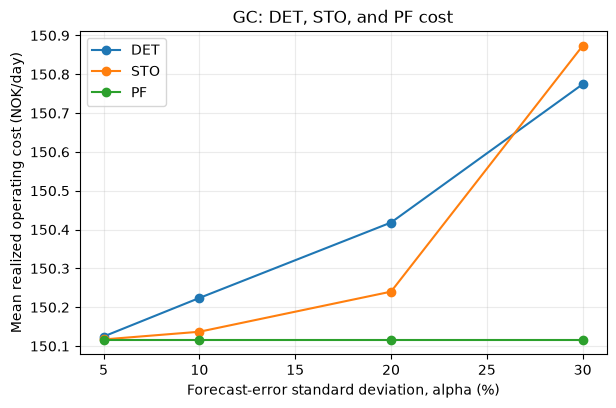

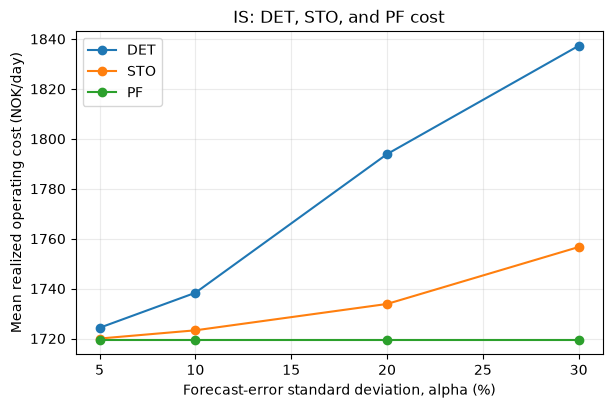

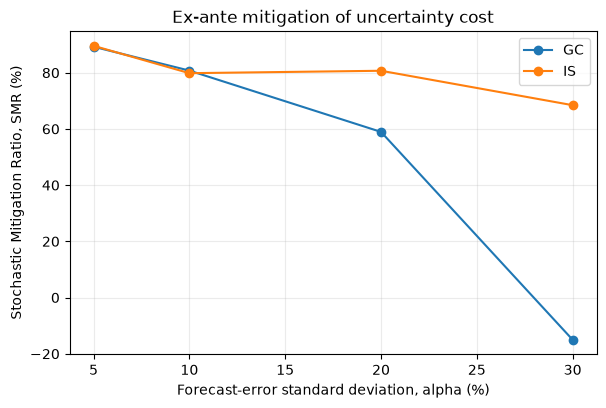

In [40]:

def plot_final_summary(final_summary):
    for mode in ["GC", "IS"]:
        g = final_summary[final_summary["mode"] == mode].sort_values("alpha")

        fig, ax = plt.subplots(figsize=(6.8, 4.2))
        ax.plot(g["alpha"] * 100, g["det_mean_cost_nok"], marker="o", label="DET")
        ax.plot(g["alpha"] * 100, g["sto_mean_cost_nok"], marker="o", label="STO")
        ax.plot(g["alpha"] * 100, g["pf_mean_cost_nok"], marker="o", label="PF")
        ax.set_xlabel("Forecast-error standard deviation, alpha (%)")
        ax.set_ylabel("Mean realized operating cost (NOK/day)")
        ax.set_title(f"{mode}: DET, STO, and PF cost")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.show()

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    for mode, g in final_summary.groupby("mode"):
        g = g.sort_values("alpha")
        ax.plot(g["alpha"] * 100, g["smr_percent"], marker="o", label=mode)
    ax.set_xlabel("Forecast-error standard deviation, alpha (%)")
    ax.set_ylabel("Stochastic Mitigation Ratio, SMR (%)")
    ax.set_title("Ex-ante mitigation of uncertainty cost")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

plot_final_summary(final_summary)



# Optional clean full rerun

The current project does **not** need this section if the original 1016-case CSV exists and the strict-PF correction above passes.

For future reproducibility, a clean full rerun should use `solver_main` consistently for DET, STO, and PF, with explicit MIP tolerances. The current corrected dataset is the recommended baseline for continuing to MPC because it preserves the completed DET/STO experiment and corrects only the benchmark solver-gap artifact.


In [13]:
import pandas as pd
from pathlib import Path
import numpy as np

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS"

)

# ---- computation time ----
df = pd.read_csv(base/"final_oos_det_sto_mpc_pf_daily.csv")

comp = {
    "DET": df["det_solve_time_s"].mean(),
    "STO": df["sto_solve_time_s"].mean(),
    "MPC": df["mpc_total_solve_time_s"].mean(),
    "PF":  df["pf_solve_time_s"].mean()
}

print("Average computation time (s)")
print(pd.Series(comp))


# ---- BESS throughput ----
# if hourly files are stored separately

throughput = {
    "DET": [],
    "STO": [],
    "MPC": [],
    "PF": []
}

for f in base.glob("*_hourly.csv"):

    name = f.name.lower()

    if "det" in name:
        key="DET"
    elif "sto" in name:
        key="STO"
    elif "mpc" in name:
        key="MPC"
    elif "pf" in name:
        key="PF"
    else:
        continue

    x=pd.read_csv(f)

    if "charge" in x.columns and "discharge" in x.columns:
        throughput[key].append(
            (x["charge"]+x["discharge"]).sum()
        )


print("\nAverage BESS throughput (kWh)")
for k,v in throughput.items():
    print(k, np.mean(v))

Average computation time (s)
DET    0.133482
STO    3.466781
MPC    1.707547
PF     0.064516
dtype: float64

Average BESS throughput (kWh)
DET nan
STO nan
MPC nan
PF nan


C:\Users\sheik\miniconda3\envs\rye-microgrid\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\sheik\miniconda3\envs\rye-microgrid\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
print(df.columns.tolist())
print(df.head())

['date', 'mode', 'alpha', 'det_cost_nok', 'sto_cost_nok', 'pf_cost_nok', 'cou_nok', 'sto_savings_vs_det_nok', 'sto_residual_gap_vs_pf_nok', 'det_critical_eens_kwh', 'sto_critical_eens_kwh', 'pf_critical_eens_kwh', 'det_noncritical_eens_kwh', 'sto_noncritical_eens_kwh', 'pf_noncritical_eens_kwh', 'det_critical_interrupted', 'sto_critical_interrupted', 'pf_critical_interrupted', 'det_diesel_kwh', 'sto_diesel_kwh', 'pf_diesel_kwh', 'det_curtailment_kwh', 'sto_curtailment_kwh', 'pf_curtailment_kwh', 'det_grid_import_kwh', 'sto_grid_import_kwh', 'pf_grid_import_kwh', 'det_grid_export_kwh', 'sto_grid_export_kwh', 'pf_grid_export_kwh', 'det_solve_time_s', 'sto_solve_time_s', 'sto_recourse_time_s', 'pf_solve_time_s', 'det_max_simultaneous_buy_sell_kw', 'sto_max_simultaneous_buy_sell_kw', 'pf_max_simultaneous_buy_sell_kw']
         date mode  alpha  det_cost_nok  sto_cost_nok  pf_cost_nok  \
0  2020-11-01   GC   0.05    -27.918323    -27.918323   -27.918323   
1  2020-11-01   IS   0.05    221.2

In [15]:
from pathlib import Path

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS"
)

for f in base.rglob("*.csv"):
    print(f.name)

final_oos_det_sto_mpc_pf_daily.csv
final_oos_det_sto_pf_checkpoint.csv
final_oos_det_sto_pf_daily.csv
final_oos_det_sto_pf_daily_CORRECTED.csv
final_oos_det_sto_pf_summary_CORRECTED.csv
forced_outage_representative_2020-11-19_det_hourly.csv
forced_outage_representative_2020-11-19_mpc_hourly.csv
forced_outage_representative_2020-11-19_pf_hourly.csv
forced_outage_representative_2020-11-19_sto_hourly.csv
forced_outage_stress_2021-02-02_det_hourly.csv
forced_outage_stress_2021-02-02_mpc_hourly.csv
forced_outage_stress_2021-02-02_pf_hourly.csv
forced_outage_stress_2021-02-02_sto_hourly.csv
strict_pf_127days.csv
strict_pf_127days_checkpoint.csv
final_oos_det_sto_pf_checkpoint-checkpoint.csv
final_oos_det_sto_pf_daily-checkpoint.csv
rye_development_304days.csv
rye_oos_127days.csv


In [17]:
import pandas as pd
from pathlib import Path

base = Path(
r"E:\AIUB Ref. Book & Class Materials\MASTERS\2ND SEMESTER\OPTIMIZATION OF POWER SYSTEM OPERATION\FINAL TERM\Simulation\Rye_Microgrid_Final_STO_OOS"
)

df = pd.read_csv(base/"rye_oos_127days.csv")

print(df.shape)
print(df.columns.tolist())

(3048, 15)
['time_utc', 'date_utc', 'hour_utc', 'split', 'source_file', 'pv_raw_kw', 'pv_clean_kw', 'wind_raw_kw', 'wind_clean_kw', 'load_kw', 'critical_load_kw', 'noncritical_load_kw', 'spot_price_nok_per_kwh', 'buy_price_nok_per_kwh', 'sell_price_nok_per_kwh']
